### Follow Up - M4 Notebook

Use this notebook to follow along and practice the concepts covered in class.

#### What´s a time series and what are its components?

In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Reading the table data
df = pd.read_csv("/content/drive/MyDrive/Elogroup/CNH data literacy/Data League/Aula M4/Follow up/m4_dataset.csv")

In [7]:
# Visualizing table
df

,InvoiceDate,Sales,Quantity
0,2010-12-01,58960.79,27007
1,2010-12-02,47748.38,31348
2,2010-12-03,46943.71,16471
3,2010-12-04,0.00,0
4,2010-12-05,31774.95,16451
...,...,...,...
369,2011-12-05,88741.96,44664
370,2011-12-06,56713.21,30469
371,2011-12-07,75439.16,41980
372,2011-12-08,82495.00,35672


**Dataset Description**

This dataset provides daily records of global sales transactions from a retail store. It captures the sales activity over time, including both the number of items sold and the total revenue generated.

Columns:

InvoiceDate → Timestamp of each transaction (daily granularity)

Sales → Total sales revenue generated during that day

Quantity → Total number of items sold during that day

A time series consists of data points collected at regular time intervals.

Example:

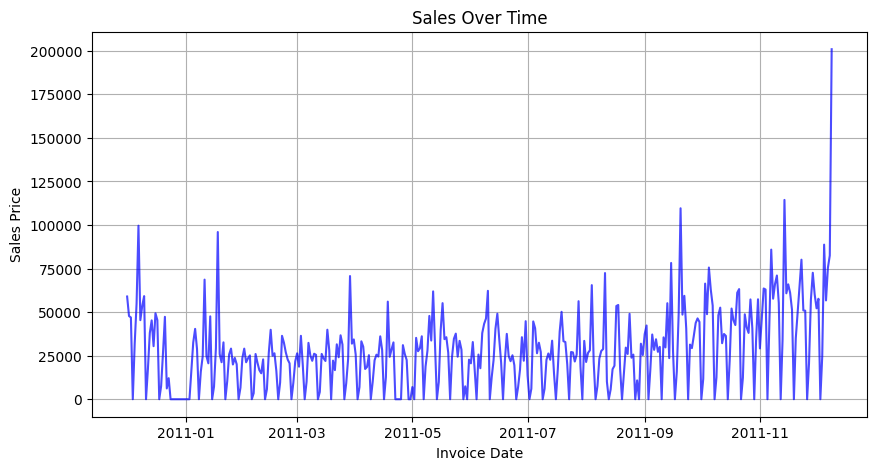

In [8]:
df_temp = df.copy()

# Ensure InvoiceDate is datetime
df_temp["InvoiceDate"] = pd.to_datetime(df_temp["InvoiceDate"])

# Sort by time (important for time series)
df_temp = df_temp.sort_values("InvoiceDate")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_temp["InvoiceDate"], df_temp["Sales"], color="blue", alpha=0.7)

plt.title("Sales Over Time")
plt.xlabel("Invoice Date")
plt.ylabel("Sales Price")
plt.grid(True)
plt.show()

This was an example of univariate time series. We only have the date part and one feature variable (Sales)

Time series data can also be multivariate.

When more than one variable evolves over time, all of them can be used in the modeling process.

* Multiple time-dependent features can be combined

* If the series are correlated, using them together can improve model performance

* Additional variables often provide more context, leading to stronger and more accurate forecasts

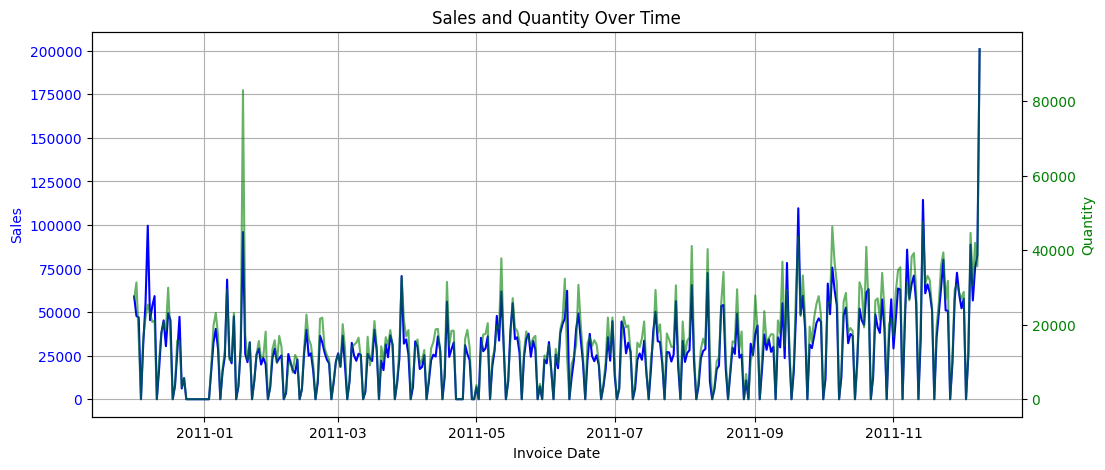

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_temp["InvoiceDate"], df_temp["Sales"], color="blue", label="Sales")
ax1.set_ylabel("Sales", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df_temp["InvoiceDate"], df_temp["Quantity"], color="green", label="Quantity", alpha=0.6)
ax2.set_ylabel("Quantity", color="green")
ax2.tick_params(axis="y", labelcolor="green")

ax1.set_title("Sales and Quantity Over Time")
ax1.set_xlabel("Invoice Date")
ax1.grid(True)

plt.show()

**Time Series Components**

A time series is typically composed of several underlying components:

* Trend

  The long-term direction of the data (upward, downward, or stable).

* Seasonality

  Regular, repeating patterns that occur at fixed intervals (daily, weekly, monthly, etc.).

* Noise (Irregular Component)

  Random fluctuations that cannot be explained by trend or seasonality.

Understanding these components helps in analyzing, modeling, and forecasting time series data more effectively.

You can break the time series components in this way:

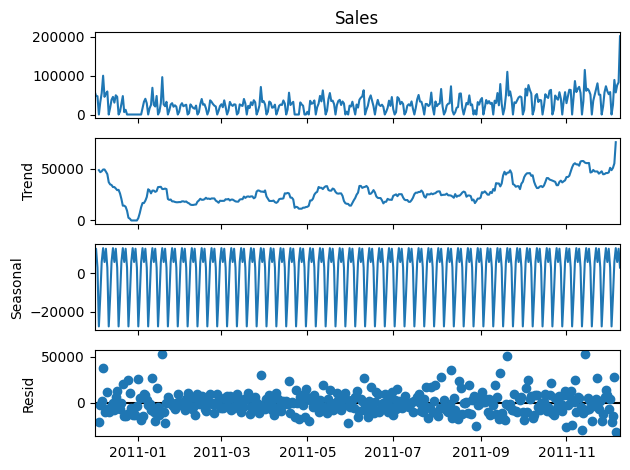

In [10]:
# Ensure InvoiceDate is datetime and sort
df_temp["InvoiceDate"] = pd.to_datetime(df_temp["InvoiceDate"])
df_temp = df_temp.sort_values("InvoiceDate")

# Set InvoiceDate as index
df_ts = df_temp.set_index("InvoiceDate")["Sales"]

decomposition = seasonal_decompose(df_ts.dropna(), model='additive', period=7)  # period=7 for weekly seasonality as the data is daily
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

decomposition.plot()
plt.show()


We can check each plot individually, and also do it by hand to understand how it works.

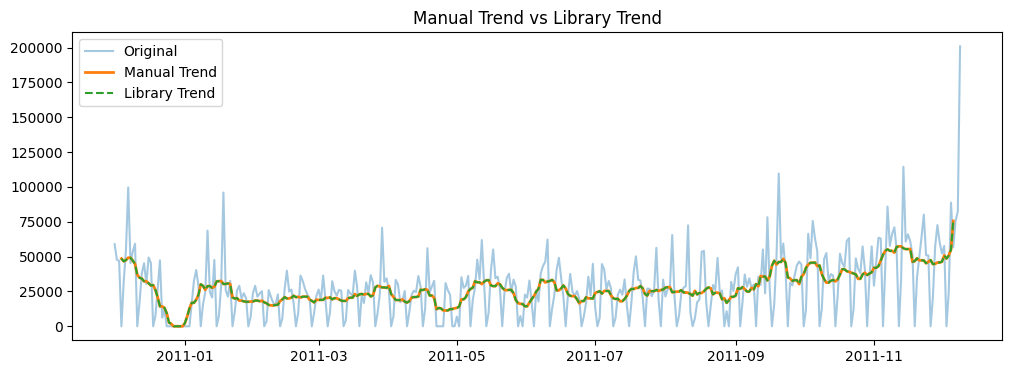

In [11]:
period = 7

trend_manual = df_ts.rolling(window=period, center=True).mean()

plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original", alpha=0.4)
plt.plot(trend_manual, label="Manual Trend", linewidth=2)
plt.plot(trend, label="Library Trend", linestyle="--")

plt.title("Manual Trend vs Library Trend")
plt.legend()
plt.show()

In [12]:
detrended = df_ts - trend_manual

seasonal_pattern = detrended.groupby(detrended.index.dayofweek).mean()

seasonal_manual = df_ts.index.dayofweek.map(seasonal_pattern)
seasonal_manual = pd.Series(
    seasonal_manual,
    index=df_ts.index
)

It's best to show one or two cycles for seasonality, since they are the same.

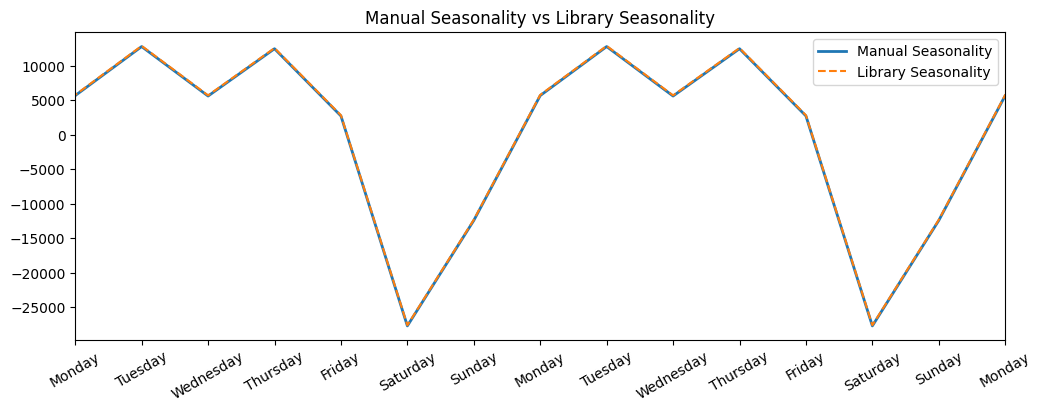

In [13]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))

plt.plot(seasonal_manual, label="Manual Seasonality", linewidth=2)
plt.plot(seasonal, label="Library Seasonality", linestyle="--")

# show only two weeks
start = df_ts.index.min() + pd.Timedelta(days=5)
end = start + pd.Timedelta(days=14)

plt.xlim(start, end)

# show name of the day of the week on x axis
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%A"))
plt.xticks(rotation=30)

plt.title("Manual Seasonality vs Library Seasonality")
plt.legend()
plt.show()

The trend and seasonality components can be leveraged for deeper descriptive analysis, helping to uncover additional insights from the data.

#### 3. Data Quality and Reliability

Let´s see if our data has some data quality problem!

**Missing Data**

In [14]:
df_temp = df.copy()

# Ensure InvoiceDate is datetime
df_temp["InvoiceDate"] = pd.to_datetime(df_temp["InvoiceDate"])

# Setting InvoiceDate as datetime index
df_temp = df_temp.set_index('InvoiceDate').sort_index()

In [15]:
df_temp

,Sales,Quantity
InvoiceDate,,
2010-12-01,58960.79,27007
2010-12-02,47748.38,31348
2010-12-03,46943.71,16471
2010-12-04,0.00,0
2010-12-05,31774.95,16451
...,...,...
2011-12-05,88741.96,44664
2011-12-06,56713.21,30469
2011-12-07,75439.16,41980


In [16]:
print(f"Our data goes from {df_temp.index.min()} to {df_temp.index.max()}")

Our data goes from 2010-12-01 00:00:00 to 2011-12-09 00:00:00


In [17]:
# Checking if data has daily gaps, missing days
full_range = pd.date_range(start=df_temp.index.min(), end=df_temp.index.max(), freq='D')
missing_days = full_range.difference(df_temp.index)
print("Missing days:", missing_days)
# We don't have any missing days

Missing days: DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [18]:
# Let´s look for null values or infinity values, it can be considered as a missing value

# Check if any column has nulls
print(df_temp.isnull().sum())
# No nulls on data

Sales       0
Quantity    0
dtype: int64


There are no nulls on the data. But we will simulate them to practice how to fill it.


In [19]:
# Create a copy to simulate missing values
df_missing = df_temp["Sales"].copy()

# Create artificial missing values
df_missing.iloc[30:100] = np.nan

# Check missing values now
print(df_missing.isnull().sum())

70


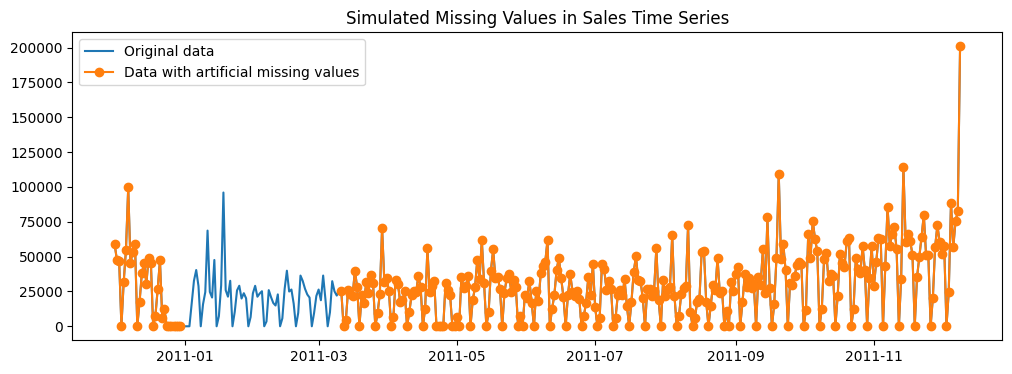

In [20]:
plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original data")
plt.plot(df_missing, label="Data with artificial missing values", marker="o")

plt.title("Simulated Missing Values in Sales Time Series")
plt.legend()
plt.show()

Forward fill

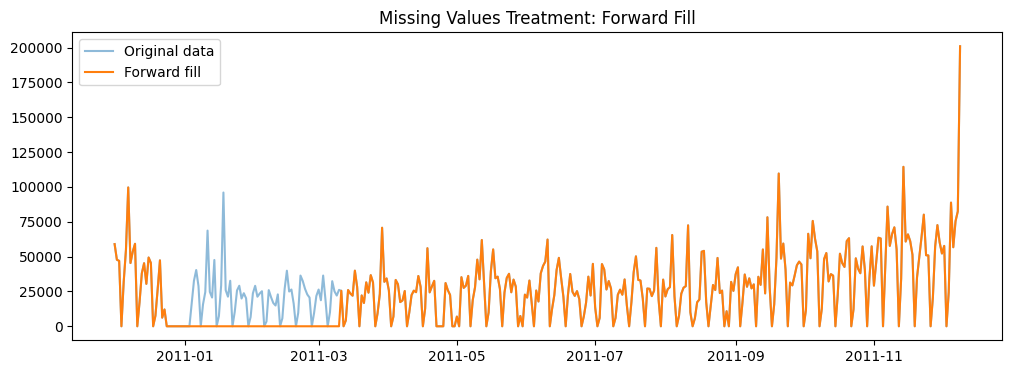

In [21]:
df_ffill = df_missing.ffill()

plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original data", alpha=0.5)
plt.plot(df_ffill, label="Forward fill")

plt.title("Missing Values Treatment: Forward Fill")
plt.legend()
plt.show()

Backward fill

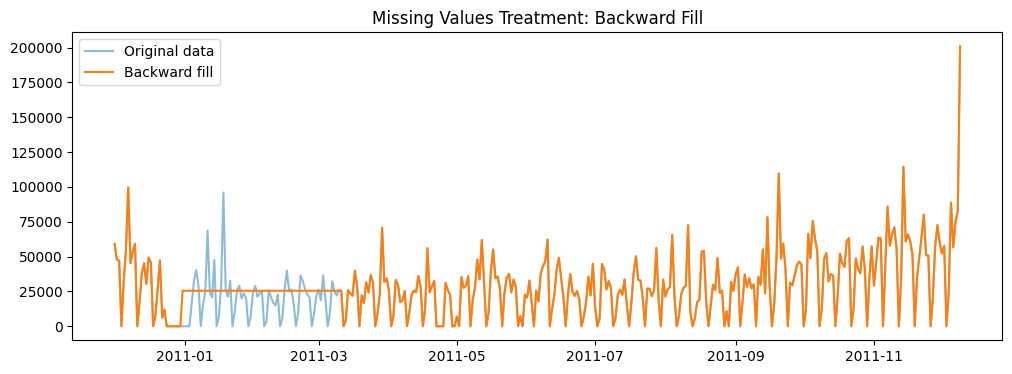

In [22]:
df_bfill = df_missing.bfill()

plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original data", alpha=0.5)
plt.plot(df_bfill, label="Backward fill")

plt.title("Missing Values Treatment: Backward Fill")
plt.legend()
plt.show()

Interpolation

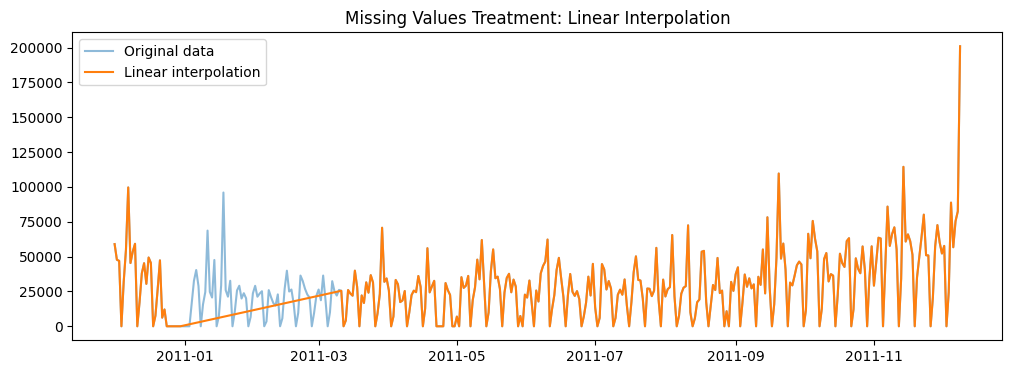

In [23]:
df_linear = df_missing.interpolate(method="linear")

plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original data", alpha=0.5)
plt.plot(df_linear, label="Linear interpolation")

plt.title("Missing Values Treatment: Linear Interpolation")
plt.legend()
plt.show()

Seasonality + interpolation

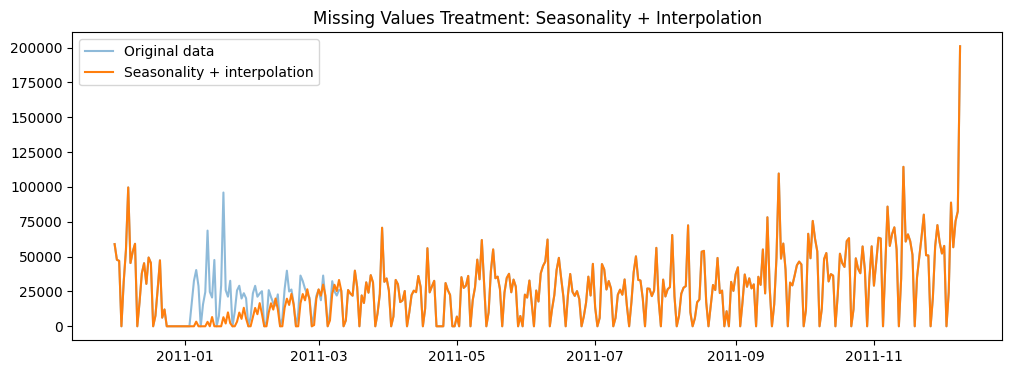

In [24]:
# Calculate weekly seasonal pattern
seasonal_pattern = df_missing.groupby(df_missing.index.dayofweek).mean()

# Create seasonal component for each date
seasonal_component = pd.Series(
    df_missing.index.dayofweek.map(seasonal_pattern),
    index=df_missing.index
)

# Remove seasonality
deseasonalized = df_missing - seasonal_component

# Interpolate the deseasonalized series
deseasonalized_interp = deseasonalized.interpolate(method="time")

# Add seasonality back
df_seasonal_interp = deseasonalized_interp + seasonal_component

# Replace negative values with 0
df_seasonal_interp = df_seasonal_interp.clip(lower=0)

plt.figure(figsize=(12, 4))

plt.plot(df_ts, label="Original data", alpha=0.5)
plt.plot(df_seasonal_interp, label="Seasonality + interpolation")

plt.title("Missing Values Treatment: Seasonality + Interpolation")
plt.legend()
plt.show()

In [25]:
# Check if any column has infinite values
print(np.isinf(df_temp).sum())
# No infinities on data

Sales       0
Quantity    0
dtype: int64


**Data Inconsistence**

In [26]:
# Let´s see if data has some duplicated lines for the same timestamp

# Check if there are any duplicate timestamps
duplicates_exist = df_temp.index.duplicated().any()
print("Any duplicate timestamps?", duplicates_exist)
# No duplicated timestamps

Any duplicate timestamps? False


In [27]:
# Let's check if the 'Sales' and 'Quantity' features have any issues.
# We know that 'Sales' should always be >= 0, since negative revenue is not possible,
# and 'Quantity' should also be >= 0, because we cannot sell a negative number of products.

print(df_temp["Sales"].min())
print(df_temp["Sales"].max())
print(df_temp["Sales"].mean())
print(df_temp["Sales"].std())

0.0
200920.6
28461.39150802139
23426.85217641175


In [28]:
print(df_temp["Quantity"].min())
print(df_temp["Quantity"].max())
print(df_temp["Quantity"].mean())
print(df_temp["Quantity"].std())

0
93979
15136.312834224598
12061.078158227383


In [29]:
# We don´t have any sales or quantity negative

**Outliers**

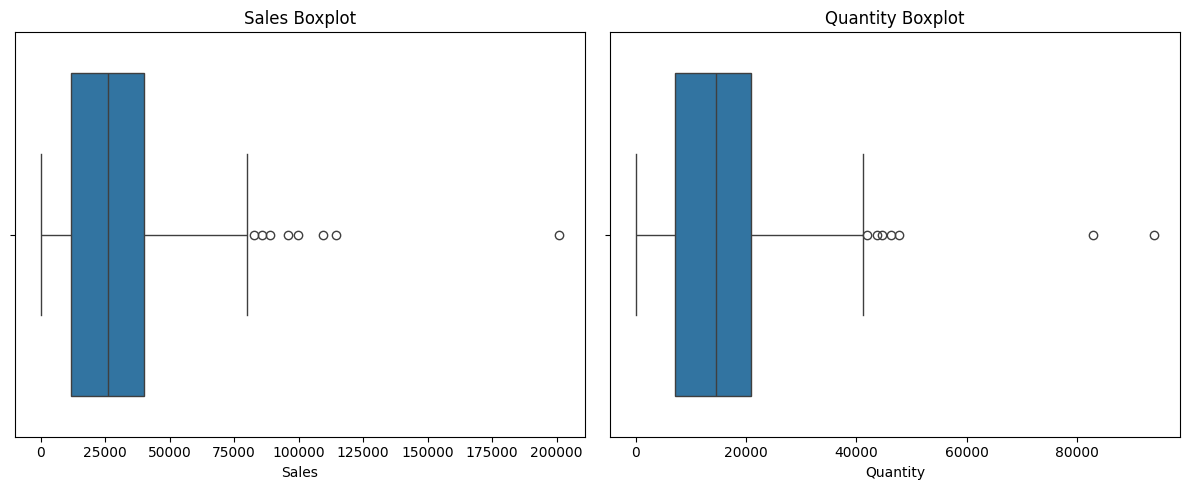

In [30]:
# Do we have huge outliers in the sale and quantity?

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Boxplot for Sales
sns.boxplot(x=df_temp['Sales'], ax=axes[0])
axes[0].set_title("Sales Boxplot")

# Boxplot for Quantity
sns.boxplot(x=df_temp['Quantity'], ax=axes[1])
axes[1].set_title("Quantity Boxplot")

plt.tight_layout()  # Adjust spacing
plt.show()

# We have some outliers here

In [31]:
# Calculate the treshold outlier for filtering using the IQR method for Sales
Q1 = df_temp['Sales'].quantile(0.25)
Q3 = df_temp['Sales'].quantile(0.75)
IQR = Q3 - Q1

#low_outlier = Q1 - 1.5*IQR
high_outlier_sales = Q3 + 1.5*IQR

# We only need the high/upper outlier as our data cannot go below 0

print(f"Any Sales bigger than {high_outlier_sales} will be an outlier")

Any Sales bigger than 82126.7125 will be an outlier


In [32]:
# Calculate the treshold outlier for filtering using the IQR method for Quantity
Q1 = df_temp['Quantity'].quantile(0.25)
Q3 = df_temp['Quantity'].quantile(0.75)
IQR = Q3 - Q1

#low_outlier = Q1 - 1.5*IQR
high_outlier_quantity = Q3 + 1.5*IQR

# We only need the high/upper outlier as our data cannot go below 0

print(f"Any Quantity bigger than {high_outlier_quantity} will be an outlier")

Any Quantity bigger than 41556.625 will be an outlier


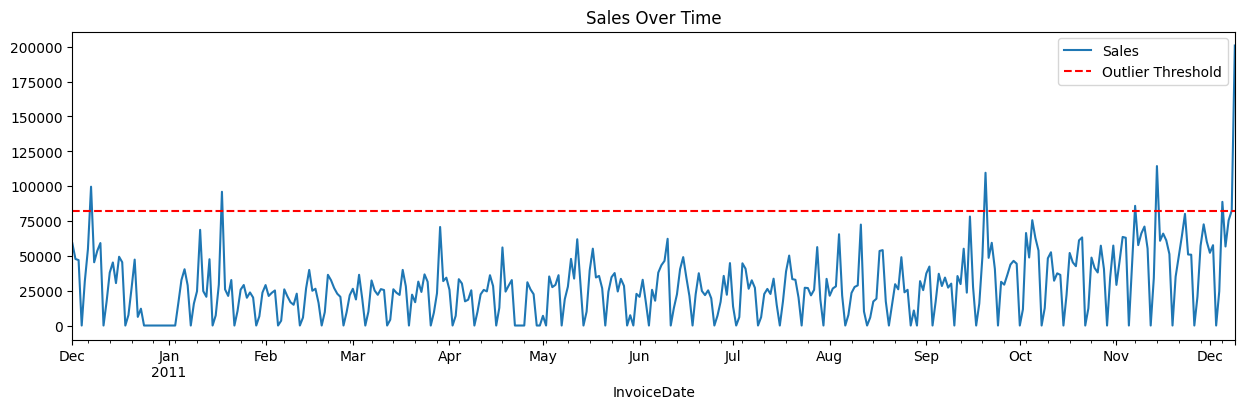

In [33]:
# Visualizing the outlier line on Sales
df_temp.plot(y='Sales', figsize=(15,4))
plt.title("Sales Over Time")

# Add a horizontal red line at the outlier threshold
plt.axhline(y=high_outlier_sales, color='red', linestyle='--', label='Outlier Threshold')

plt.legend()
plt.show()

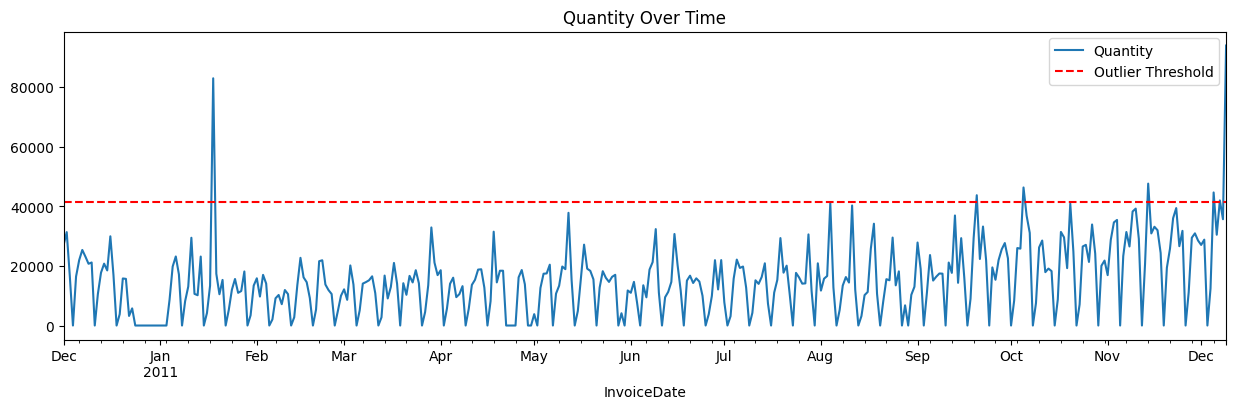

In [34]:
# Visualizing the outlier line on Quantity
df_temp.plot(y='Quantity', figsize=(15,4))
plt.title("Quantity Over Time")

# Add a horizontal red line at the outlier threshold
plt.axhline(y=high_outlier_quantity, color='red', linestyle='--', label='Outlier Threshold')

plt.legend()
plt.show()

In [35]:
# Counting how many outliers data points we have
df_temp[(df_temp["Sales"] > high_outlier_sales) | (df_temp["Quantity"] > high_outlier_quantity)]

,Sales,Quantity
InvoiceDate,,
2010-12-07,99618.20,25365
2011-01-18,95978.05,82978
2011-09-20,109612.03,43733
2011-10-05,75593.63,46338
2011-11-07,85881.81,31395
2011-11-14,114419.89,47631
2011-12-05,88741.96,44664
2011-12-07,75439.16,41980
2011-12-08,82495.00,35672


In [36]:
# We have just 10 outliers data points
len(df_temp[(df_temp["Sales"] > high_outlier_sales) | (df_temp["Quantity"] > high_outlier_quantity)]) / len(df_temp)

# Just 2.6% of the data is outlier.

0.026737967914438502

No major inconsistencies were identified in this dataset. The detected outliers can be addressed later during the modeling stage or left as they are, depending on the requirements and assumptions of the chosen model.

#### 4. Steps in Predictive Analysis

**Cleaning and Preparation**

In this stage, we prepare the dataset for modeling by addressing any issues identified during the exploratory data analysis (EDA). This includes handling missing values, resolving inconsistencies, managing outliers, splitting the data into training, validation, and test sets, and applying normalization where necessary.

* Handling Missing Data

Based on our exploratory analysis, no missing values were identified in the dataset. Therefore, no imputation or removal is required, and the data will be used as is.

* Handling Inconsistencies

The exploratory analysis did not reveal any inconsistencies in the data. As a result, no corrective actions are necessary, and the dataset will be retained in its original form.

* Dealing with Outliers

Some outliers were identified during the exploratory analysis. However, these outliers account for only 2.6% of the dataset. Given their limited proportion and the fact that they may represent rare but valid events, we choose to retain them. Their impact on the final model is expected to be minimal, and treating them as legitimate observations allows the model to learn from infrequent but meaningful patterns.

* Resampling and Frequency Adjustment

The dataset is recorded at a daily frequency, which aligns with the modeling objective of predicting daily events. Therefore, no resampling or frequency adjustment is required.

In [37]:
# Adjusting the data format of the dataset

In [38]:
time_series_df = df.copy()

# Ensure InvoiceDate is datetime
time_series_df["InvoiceDate"] = pd.to_datetime(time_series_df["InvoiceDate"])

# Setting InvoiceDate as datetime index
time_series_df = time_series_df.set_index('InvoiceDate').sort_index()

In [39]:
# Visualizing the indexed time series
time_series_df

,Sales,Quantity
InvoiceDate,,
2010-12-01,58960.79,27007
2010-12-02,47748.38,31348
2010-12-03,46943.71,16471
2010-12-04,0.00,0
2010-12-05,31774.95,16451
...,...,...
2011-12-05,88741.96,44664
2011-12-06,56713.21,30469
2011-12-07,75439.16,41980


* Train/Valid/Test Split

The dataset will be divided into training, validation, and test sets using a time-based split. The most recent month of data will be reserved for the test set, the preceding month will be used as the validation set, and all remaining historical data will form the training set.

This approach preserves the temporal order of the data, ensuring that the model is trained on past observations and evaluated on future data, which closely reflects real-world forecasting conditions.

In [40]:
# Identify date boundaries
last_date = time_series_df.index.max()
test_start = last_date - pd.DateOffset(months=1)
valid_start = test_start - pd.DateOffset(months=1)

# Split the data
train_df = time_series_df[time_series_df.index < valid_start]
valid_df = time_series_df[(time_series_df.index >= valid_start) & (time_series_df.index < test_start)]
test_df  = time_series_df[time_series_df.index >= test_start]

# Optional: sanity check
print("Train:", train_df.index.min(), "→", train_df.index.max())
print("Valid:", valid_df.index.min(), "→", valid_df.index.max())
print("Test :", test_df.index.min(), "→", test_df.index.max())

# Now we have the dataset splitted

Train: 2010-12-01 00:00:00 → 2011-10-08 00:00:00
Valid: 2011-10-09 00:00:00 → 2011-11-08 00:00:00
Test : 2011-11-09 00:00:00 → 2011-12-09 00:00:00


**Model - Moving Average**

For a moving average (MA) model, there are no model weights to estimate, unlike in regression or neural networks. The only parameter we need to select is the window size 𝑘, which determines how many past observations are averaged to make a prediction.

Key points:

No training required:

 - The model does not “learn” weights.

 - Predictions are made by computing the average of the last k observations.

Parameter selection (choosing 𝑘):

 - The best 𝑘 can be determined by testing different window sizes on the training set.

Normalization is not necessary:

 - Since the moving average uses the original scale of the data, scaling or normalization is not required.

In [41]:
train_ma = train_df.copy()["Sales"].values
valid_ma = valid_df.copy()["Sales"].values
test_ma = test_df.copy()["Sales"].values

predict t+1 using real past values

predict t+2 using real past values + predicted t+1

predict t+3 using real past values + predicted t+1 + predicted t+2

In [42]:
def moving_average_forecast(history_series, steps, k):
    """
    Moving average forecast for future values.

    history_series: all values available before the forecast starts
    steps: how many future values to predict
    k: moving average window size

    If steps = 1:
        prediction uses only real historical values.

    If steps > 1:
        prediction 1 uses real historical values.
        prediction 2 uses real historical values + prediction 1.
        prediction 3 uses real historical values + prediction 1 + prediction 2.
        and so on.
    """

    history = list(history_series)
    predictions = []

    for i in range(steps):
        pred = np.mean(history[-k:])
        predictions.append(pred)

        # append prediction because future real values are not available yet
        history.append(pred)

    return np.array(predictions)

In [43]:
k_values = range(1, 31)
mae_scores = []

for k in k_values:
    valid_preds = moving_average_forecast(
        history_series=train_ma,
        steps=len(valid_ma),
        k=k
    )

    mae = mean_absolute_error(valid_ma, valid_preds)
    mae_scores.append(mae)

best_k = k_values[np.argmin(mae_scores)]

print(f"Best window size k: {best_k}")
print(f"Validation MAE with best k: {min(mae_scores):.2f}")

Best window size k: 15
Validation MAE with best k: 15983.48


In [44]:
valid_preds = moving_average_forecast(
    history_series=train_ma,
    steps=len(valid_ma),
    k=best_k
)

forecast_df_valid = pd.DataFrame({
    "Actual": valid_ma,
    "Predicted": valid_preds
}, index=valid_df.index)

In [45]:
train_valid_ma = np.concatenate([train_ma, valid_ma])

test_preds = moving_average_forecast(
    history_series=train_valid_ma,
    steps=len(test_ma),
    k=best_k
)

forecast_df_test = pd.DataFrame({
    "Actual": test_ma,
    "Predicted": test_preds
}, index=test_df.index)

test_mae = mean_absolute_error(test_ma, test_preds)

print(f"Test MAE with best k={best_k}: {test_mae:.2f}")

forecast_df_test.head()

Test MAE with best k=15: 26458.82


,Actual,Predicted
InvoiceDate,,
2011-11-09,66127.57,43818.840000
2011-11-10,71008.26,43985.786667
2011-11-11,55257.17,44380.877111
2011-11-12,0.00,43520.154252
2011-11-13,34069.92,43717.117869


In [46]:
train_preds = []

for i in range(best_k, len(train_ma)):

    # all real values available before point i
    history = train_ma[:i]

    # predict only the next value
    pred = moving_average_forecast(
        history_series=history,
        steps=1,
        k=best_k
    )[0]

    train_preds.append(pred)

forecast_df_train = pd.DataFrame({
    "Actual": train_ma[best_k:],
    "Predicted": train_preds
}, index=train_df.index[best_k:])

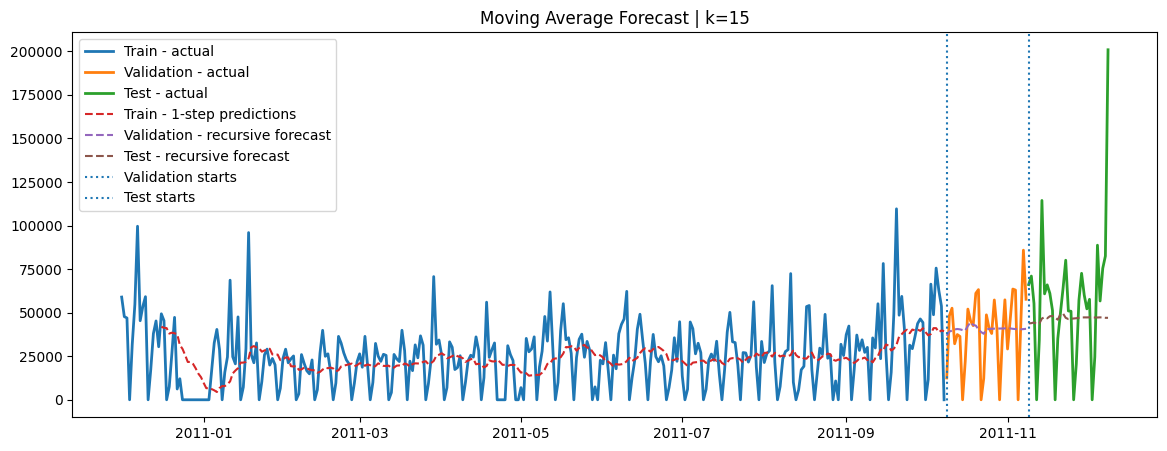

In [47]:
plt.figure(figsize=(14, 5))

# Actual values
plt.plot(train_df.index, train_ma, label="Train - actual", linewidth=2)
plt.plot(valid_df.index, valid_ma, label="Validation - actual", linewidth=2)
plt.plot(test_df.index, test_ma, label="Test - actual", linewidth=2)

# Predictions
plt.plot(
    forecast_df_train.index,
    forecast_df_train["Predicted"],
    label="Train - 1-step predictions",
    linestyle="--"
)

plt.plot(
    forecast_df_valid.index,
    forecast_df_valid["Predicted"],
    label="Validation - recursive forecast",
    linestyle="--"
)

plt.plot(
    forecast_df_test.index,
    forecast_df_test["Predicted"],
    label="Test - recursive forecast",
    linestyle="--"
)

# Split lines
plt.axvline(
    valid_df.index.min(),
    linestyle=":",
    label="Validation starts"
)

plt.axvline(
    test_df.index.min(),
    linestyle=":",
    label="Test starts"
)

plt.title(f"Moving Average Forecast | k={best_k}")
plt.legend()
plt.show()

**Model - SARIMA**

The SARIMA model is a univariate time-series model, using only the Sales series as input. Since SARIMA operates directly on the original data scale, no normalization or scaling is required.

For this activity, the parameter optimization has already been performed to identify the best combination of SARIMA parameters based on the validation set. The corresponding code has been omitted for brevity, as it was part of the parameter tuning process.

Using the selected optimal parameters, the final SARIMA model is trained on the training set and then evaluated on both the validation and test sets to assess its forecasting performance. This ensures that the model is properly tuned while avoiding overfitting to the training data.

If we do seasonal_order=(0, 0, 0, 0), it turns into a regular ARIMA model.

In [48]:
# Original Data wihout normalization

# When using SARIMA, it is important to evaluate the model on a validation set to reduce the risk of overfitting.
train_sarima = train_df.copy()["Sales"].values
valid_sarima = valid_df.copy()["Sales"].values
test_sarima = test_df.copy()["Sales"].values

In [49]:
# Train the model
best_model = SARIMAX(
    train_sarima,
    order=(0, 0, 0),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_best = best_model.fit(disp=False)

In [50]:
# Predicting the valid
valid_pred = fitted_best.forecast(steps=len(valid_sarima))
mae_valid = mean_absolute_error(valid_sarima, valid_pred)
print("Validation MAE:", mae_valid)

Validation MAE: 9732.409322284911


In [51]:
train_valid_sarima = np.concatenate([train_sarima, valid_sarima])

# Train the model
model_train_valid = SARIMAX(
    train_valid_sarima,
    order=(0, 0, 0),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_train_valid = model_train_valid.fit(disp=False)

In [52]:
# Forecast the test / Forecast from the end of training + validation
# Total steps: len(valid) + len(test), then split
total_steps = len(test_sarima)
full_forecast = fitted_train_valid.forecast(steps=total_steps)

test_pred = full_forecast

mae_test = mean_absolute_error(test_sarima, test_pred)
print("Test MAE:", mae_test)

Test MAE: 16313.914189242083


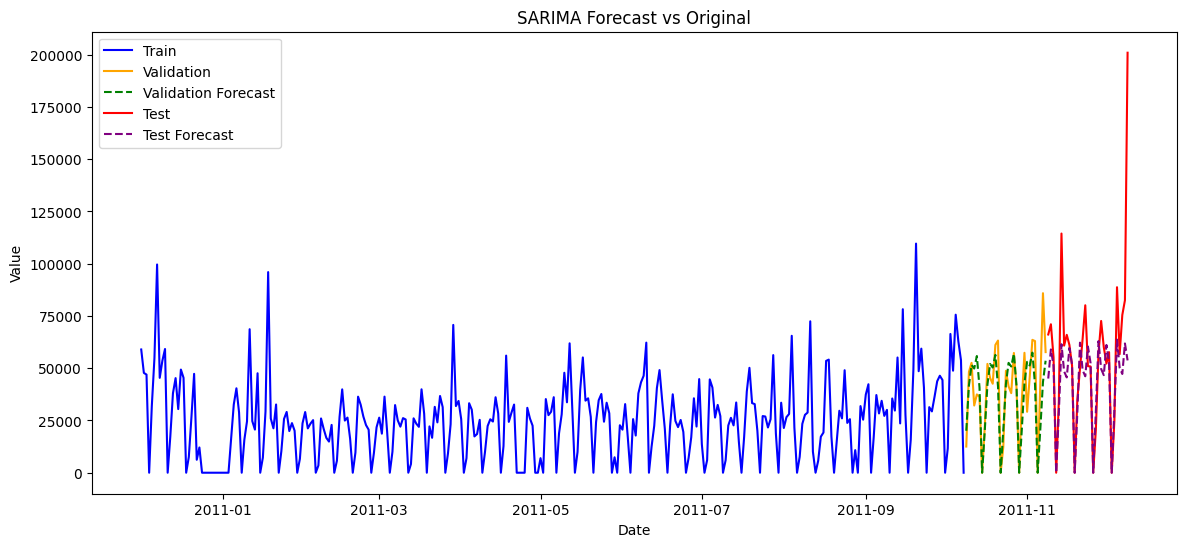

In [53]:
# Plot results
plt.figure(figsize=(14,6))
plt.plot(train_df.index, train_sarima, label='Train', color='blue')
plt.plot(valid_df.index, valid_sarima, label='Validation', color='orange')
plt.plot(valid_df.index, valid_pred, label='Validation Forecast', color='green', linestyle='--')
plt.plot(test_df.index, test_sarima, label='Test', color='red')
plt.plot(test_df.index, test_pred, label='Test Forecast', color='purple', linestyle='--')
plt.title('SARIMA Forecast vs Original')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

**Machine Learning for forecasting**

In machine learning models, we can generally use multiple features as inputs. However, most models treat features as independent per row, so to capture the temporal dependencies inherent in time series data, we need to create a lagged feature representation.

For this activity, we will use Linear Regression as our model, but the same approach can be applied to other machine learning models. Since most ML models are sensitive to feature scales, and we typically have features with different ranges, it is important to normalize the data. Normalization helps the optimization process converge more efficiently. A common choice is the Standard Scaler, which we will use here.

However, tree-based models (such as Decision Trees, Random Forests, or Gradient Boosting) are scale-invariant, meaning they do not require normalization of the input features.

To allow the model to learn temporal patterns, we will create lag features with a window of 7 time steps (i.e., one week). This gives the model a memory of the past week, enabling it to capture short-term dependencies in the data.

In [54]:
# Get the original data do add the 7 days lag

ml_data = df.copy()

# Ensure InvoiceDate is datetime
ml_data["InvoiceDate"] = pd.to_datetime(ml_data["InvoiceDate"])

# Setting InvoiceDate as datetime index
ml_data = ml_data.set_index('InvoiceDate').sort_index()

lags = 7
for lag in range(1, lags + 1):
    ml_data[f'Sales_lag_{lag}'] = ml_data['Sales'].shift(lag)
    ml_data[f'Quantity_lag_{lag}'] = ml_data['Quantity'].shift(lag)

# Drop rows with NaN values (first 7 rows)
ml_data = ml_data.dropna()

#We need to drop the Quantity column because it represents information from the current day.
#In time series forecasting, the model should only have access to past values when making predictions.
#Including the current day’s Quantity would leak information from the future into the model, which can lead to data leakage and
#overly optimistic performance. By removing it, we ensure the model learns only from historical data.
ml_data = ml_data.drop(columns=['Quantity'])

In [55]:
# Visualizing the new dataset, now in each row we have the history of the last 7 days and we want to predict the Sales of the row the next day
# Note that we are training with Sales data and Quantity to predict the Sales! We are using two time series to predict one feature.
ml_data

,Sales,Sales_lag_1,Quantity_lag_1,Sales_lag_2,Quantity_lag_2,Sales_lag_3,Quantity_lag_3,Sales_lag_4,Quantity_lag_4,Sales_lag_5,Quantity_lag_5,Sales_lag_6,Quantity_lag_6,Sales_lag_7,Quantity_lag_7
InvoiceDate,,,,,,,,,,,,,,,
2010-12-08,45389.98,99618.20,25365.0,54830.46,21951.0,31774.95,16451.0,0.00,0.0,46943.71,16471.0,47748.38,31348.0,58960.79,27007.0
2010-12-09,53586.18,45389.98,23125.0,99618.20,25365.0,54830.46,21951.0,31774.95,16451.0,0.00,0.0,46943.71,16471.0,47748.38,31348.0
2010-12-10,59182.92,53586.18,20730.0,45389.98,23125.0,99618.20,25365.0,54830.46,21951.0,31774.95,16451.0,0.00,0.0,46943.71,16471.0
2010-12-11,0.00,59182.92,21155.0,53586.18,20730.0,45389.98,23125.0,99618.20,25365.0,54830.46,21951.0,31774.95,16451.0,0.00,0.0
2010-12-12,17329.07,0.00,0.0,59182.92,21155.0,53586.18,20730.0,45389.98,23125.0,99618.20,25365.0,54830.46,21951.0,31774.95,16451.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-05,88741.96,24621.43,12412.0,0.00,0.0,57664.07,28825.0,52197.25,27051.0,60126.96,28532.0,72595.93,30940.0,57165.19,29466.0
2011-12-06,56713.21,88741.96,44664.0,24621.43,12412.0,0.00,0.0,57664.07,28825.0,52197.25,27051.0,60126.96,28532.0,72595.93,30940.0
2011-12-07,75439.16,56713.21,30469.0,88741.96,44664.0,24621.43,12412.0,0.00,0.0,57664.07,28825.0,52197.25,27051.0,60126.96,28532.0


In [56]:
# Splitting in train/valid/test
# Identify date boundaries
last_date = ml_data.index.max()
test_start = last_date - pd.DateOffset(months=1)
valid_start = test_start - pd.DateOffset(months=1)

# Split the data
train_df = ml_data[ml_data.index < valid_start]
valid_df = ml_data[(ml_data.index >= valid_start) & (ml_data.index < test_start)]
test_df  = ml_data[ml_data.index >= test_start]

In [57]:
X_train = train_df.drop(columns=['Sales']) # We remove the sales too it is our target
y_train = train_df['Sales'] # True values we want to predict

X_valid = valid_df.drop(columns=['Sales']) # We remove the sales too it is our target
y_valid = valid_df['Sales'] # True values we want to predict

X_test = test_df.drop(columns=['Sales']) # We remove the sales too it is our target
y_test = test_df['Sales'] # True values we want to predict

In [58]:
# Normalizing features
ml_scaler = StandardScaler()
X_train_scaled = ml_scaler.fit_transform(X_train)

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Train Model
model2 = RandomForestRegressor()
model2.fit(X_train_scaled, y_train)

RandomForestRegressor()

The validation set can be used to optimize hyperparameters of the machine learning model. In the case of time series, one of the most important hyperparameters is the lag window — that is, how many past time steps the model should consider as input features.

By testing different lag values on the validation set, we can select the one that minimizes the MAE (or another relevant error metric). Similarly, for other machine learning algorithms, the validation set can be used to tune model-specific parameters, such as regularization strength in Linear Regression, the number of estimators in Random Forests, or the learning rate in gradient boosting.

*We can also use it to choose the best model type (comparing ml algorithms and classical, for example).*

This approach ensures the model is well-tuned to unseen data without leaking information from the test set, which provides a more reliable estimate of future forecasting performance.

In [60]:
# Visualizing MAE metric on valid and test
y_valid_pred = model.predict(ml_scaler.transform(X_valid))
y_test_pred = model.predict(ml_scaler.transform(X_test))

mae_valid = mean_absolute_error(y_valid, y_valid_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Validation MAE Linear Regression:", mae_valid)
print("Test MAE Linear Regression:", mae_test)


# Visualizing MAE metric on valid and test
y_valid_pred2 = model2.predict(ml_scaler.transform(X_valid))
y_test_pred2 = model2.predict(ml_scaler.transform(X_test))

mae_valid2 = mean_absolute_error(y_valid, y_valid_pred2)
mae_test2 = mean_absolute_error(y_test, y_test_pred2)

print("Validation MAE Tree:", mae_valid2)
print("Test MAE Tree:", mae_test2)

Validation MAE Linear Regression: 12786.6124468321
Test MAE Linear Regression: 19872.725086949602
Validation MAE Tree: 11229.307399032255
Test MAE Tree: 15369.41811290323


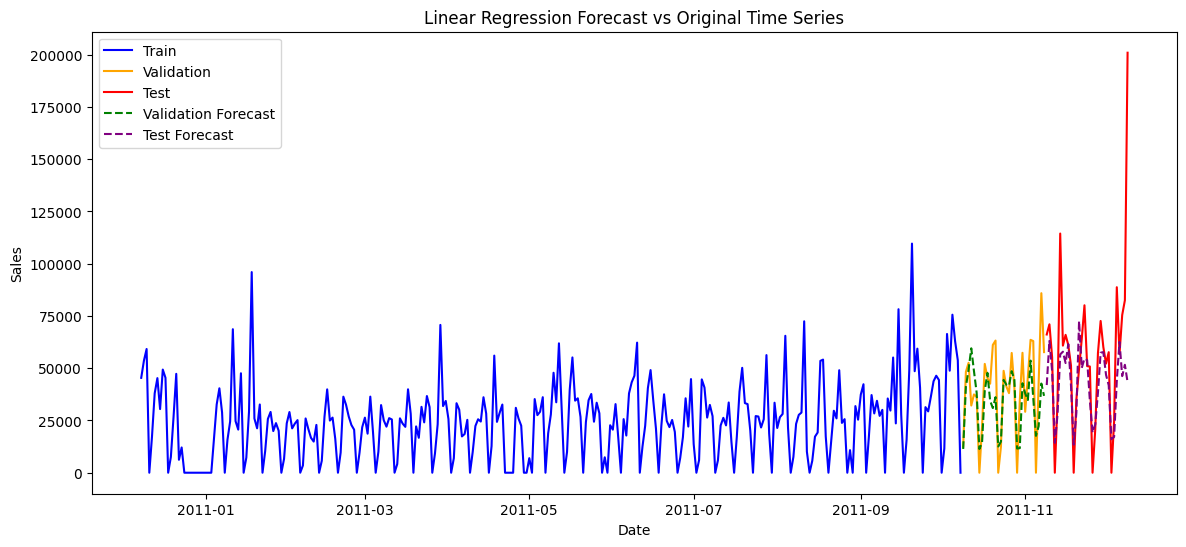

In [61]:
plt.figure(figsize=(14,6))

# Plot the original series
plt.plot(train_df.index, train_df["Sales"], label='Train', color='blue')
plt.plot(valid_df.index, valid_df["Sales"], label='Validation', color='orange')
plt.plot(test_df.index, test_df["Sales"], label='Test', color='red')

# Plot the predictions
plt.plot(valid_df.index, y_valid_pred, label='Validation Forecast', color='green', linestyle='--')
plt.plot(test_df.index, y_test_pred, label='Test Forecast', color='purple', linestyle='--')

plt.title('Linear Regression Forecast vs Original Time Series')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

### The End